# HR Attrition Model Training

This notebook trains and evaluates machine learning models to predict employee attrition.

**Goals:**
- Train baseline models (Logistic Regression, Random Forest)
- Address class imbalance
- Compare model performance
- Tune hyperparameters
- Select optimal threshold
- Choose final model with feature importance analysis

## 1. Setup & Preprocessing

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report
)
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    selection_rate
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Loading data

df = pd.read_csv("../data/hr_employee_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Dataset shape: (14999, 11)

Columns:
['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
print(f"Shape before dropping Emp_Id: {df.shape}")

df = df.drop('Emp_Id', axis=1)

print(f"Shape after dropping Emp_Id: {df.shape}")

# Checking for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape before dropping Emp_Id: (14999, 11)
Shape after dropping Emp_Id: (14999, 10)

Missing values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


## 2. Feature Engineering

In [4]:
# Checking categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())

Categorical columns: ['Department', 'salary']

Department unique values:
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

salary unique values:
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


In [2]:
# Encoding categorical variables

salary_categories = [['low', 'medium', 'high']]
salary_encoder = OrdinalEncoder(categories=salary_categories, dtype=int)

dept_encoder = OneHotEncoder(sparse_output=False, drop='first', dtype=int)

# Encode salary

df['salary_encoded'] = salary_encoder.fit_transform
(df[['salary']]).flatten()

# OneHot encode Department
dept_encoded = dept_encoder.fit_transform(df[['Department']])
dept_columns = [f'Dept_{cat}' for cat in dept_encoder.categories_[0][1:]]
for i, col in enumerate(dept_columns):    
    df[col] = dept_encoded[:, i]
    print("Encoding Mappings:")
    print(f"\nSalary (Ordinal):")
    print(f"  0: low")
    print(f"  1: medium")
    print(f"  2: high")
    print(f"\nDepartment (OneHot, baseline=accounting dropped):")
    for i, col in enumerate(dept_columns):    
        print(f"  {col}")

NameError: name 'OrdinalEncoder' is not defined

In [6]:
# Preparing feature and target columns

dept_columns = [c for c in df.columns if c.startswith('Dept_')]
feature_cols = [    
    'satisfaction_level', 
    'last_evaluation', 'number_project',    
    'average_montly_hours', 'time_spend_company', 'Work_accident',    
    'promotion_last_5years', 'salary_encoded'] + dept_columnsX = df[feature_cols]
y = df['left']
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (14999, 9)
Target vector shape: (14999,)


In [7]:
# Splitting data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Test Split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Printing class distribution
print(f"\nClass Distribution:")
print(f"Full dataset: {y.value_counts().to_dict()}")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")

print(f"\nAttrition Rate:")
print(f"Full dataset: {y.mean():.2%}")
print(f"Train: {y_train.mean():.2%}")
print(f"Test: {y_test.mean():.2%}")

Train/Test Split:
Training set: 11999 samples
Test set: 3000 samples

Class Distribution:
Full dataset: {0: 11428, 1: 3571}
Train: {0: 9142, 1: 2857}
Test: {0: 2286, 1: 714}

Attrition Rate:
Full dataset: 23.81%
Train: 23.81%
Test: 23.80%


## 3. Training the Baseline Models

In [8]:
# Scaling features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Training Logistic Regression model
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)

lr_pred = lr_baseline.predict(X_test_scaled)
lr_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Logistic Regression Results:
Accuracy: 0.7710
Precision: 0.5391
Recall: 0.2605
F1 Score: 0.3513
ROC AUC: 0.8115


In [10]:
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

rf_pred = rf_baseline.predict(X_test)
rf_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, rf_proba):.4f}")

Random Forest Results:
Accuracy: 0.9910
Precision: 0.9957
Recall: 0.9664
F1 Score: 0.9808
ROC AUC: 0.9916


## 4. Handling Uneven Data (~24% attrition rate vs ~76% staying).

In [11]:
# Showing attrition rate
attrition_rate = df['left'].mean()
print(f"Overall Attrition Rate: {attrition_rate:.2%}")
print(f"\nClass Imbalance Ratio: {attrition_rate / (1 - attrition_rate):.2f}")
print(f"(For every 1 employee who leaves, {(1 - attrition_rate) / attrition_rate:.1f} stay)")

Overall Attrition Rate: 23.81%

Class Imbalance Ratio: 0.31
(For every 1 employee who leaves, 3.2 stay)


In [12]:
lr_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

rf_balanced = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Comparing model performance

In [13]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

comparison = pd.DataFrame({
    'LR (No Weight)': get_metrics(y_test, lr_pred, lr_proba),
    'LR (Balanced)': get_metrics(y_test, lr_balanced.predict(X_test_scaled), lr_balanced.predict_proba(X_test_scaled)[:, 1]),
    'RF (No Weight)': get_metrics(y_test, rf_pred, rf_proba),
    'RF (Balanced)': get_metrics(y_test, rf_balanced.predict(X_test), rf_balanced.predict_proba(X_test)[:, 1])
}).T

print("Model Comparison: Without vs With Class Weighting")
comparison.style.format('{:.4f}')

Model Comparison: Without vs With Class Weighting


,accuracy,precision,recall,f1,roc_auc
LR (No Weight),0.7710,0.5391,0.2605,0.3513,0.8115
LR (Balanced),0.7663,0.5059,0.7843,0.6150,0.8235
RF (No Weight),0.9910,0.9957,0.9664,0.9808,0.9916
RF (Balanced),0.9910,0.9957,0.9664,0.9808,0.9913


### Plotting the Precision-Recall Curves

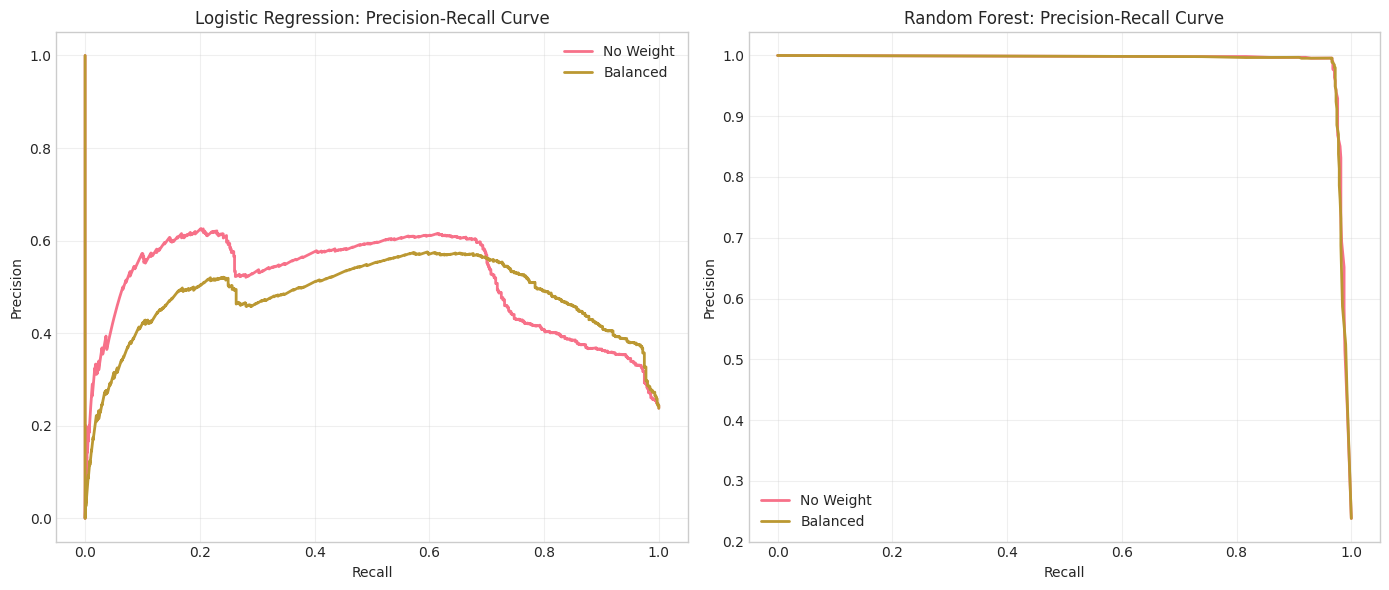

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression Algorithm
lr_proba_no_weight = lr_baseline.predict_proba(X_test_scaled)[:, 1]
lr_proba_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

precision_lr_nw, recall_lr_nw, _ = precision_recall_curve(y_test, lr_proba_no_weight)
precision_lr_bal, recall_lr_bal, _ = precision_recall_curve(y_test, lr_proba_balanced)

axes[0].plot(recall_lr_nw, precision_lr_nw, label='No Weight', linewidth=2)
axes[0].plot(recall_lr_bal, precision_lr_bal, label='Balanced', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Logistic Regression: Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest Algorithm
rf_proba_no_weight = rf_baseline.predict_proba(X_test)[:, 1]
rf_proba_balanced = rf_balanced.predict_proba(X_test)[:, 1]

precision_rf_nw, recall_rf_nw, _ = precision_recall_curve(y_test, rf_proba_no_weight)
precision_rf_bal, recall_rf_bal, _ = precision_recall_curve(y_test, rf_proba_balanced)

axes[1].plot(recall_rf_nw, precision_rf_nw, label='No Weight', linewidth=2)
axes[1].plot(recall_rf_bal, precision_rf_bal, label='Balanced', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Random Forest: Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparing accuracy, and recall

In [15]:
# Creating comprehensive metrics table
models = {
    'Logistic Regression': (lr_baseline, X_test_scaled),
    'Logistic Regression (Balanced)': (lr_balanced, X_test_scaled),
    'Random Forest': (rf_baseline, X_test),
    'Random Forest (Balanced)': (rf_balanced, X_test)
}

results = []
for name, (model, X_test_data) in models.items():
    pred = model.predict(X_test_data)
    proba = model.predict_proba(X_test_data)[:, 1]
    metrics = get_metrics(y_test, pred, proba)
    results.append({**metrics, 'Model': name})

results_df = pd.DataFrame(results).set_index('Model')
print("Complete Model Comparison:")
results_df.style.format('{:.4f}').background_gradient(cmap='YlGnBu', axis=0)

Complete Model Comparison:


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.7710,0.5391,0.2605,0.3513,0.8115
Logistic Regression (Balanced),0.7663,0.5059,0.7843,0.6150,0.8235
Random Forest,0.9910,0.9957,0.9664,0.9808,0.9916
Random Forest (Balanced),0.9910,0.9957,0.9664,0.9808,0.9913


### Plotting ROC Curves

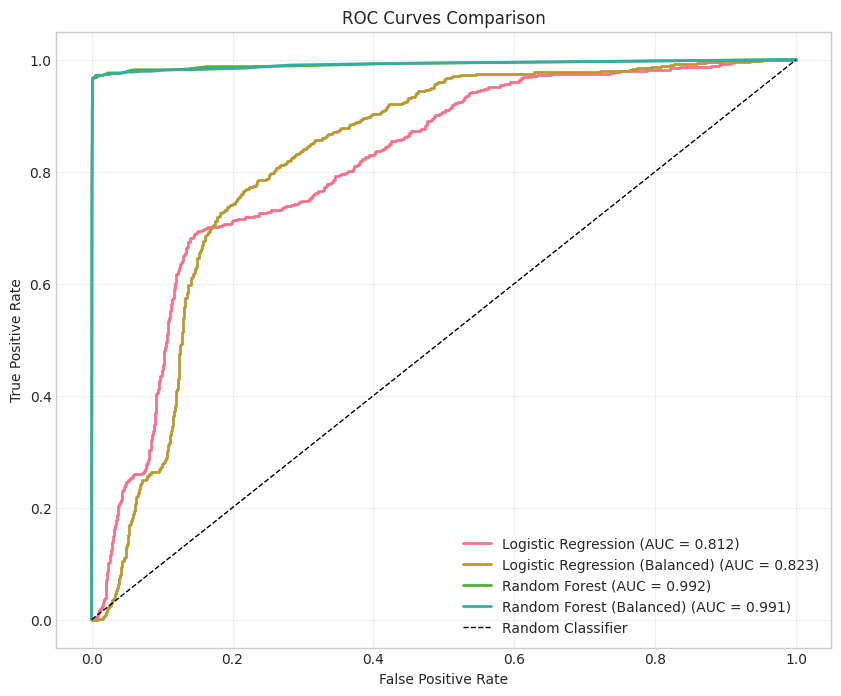

In [16]:
plt.figure(figsize=(10, 8))

for name, (model, X_test_data) in models.items():
    proba = model.predict_proba(X_test_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Plotting Confusion Matrices

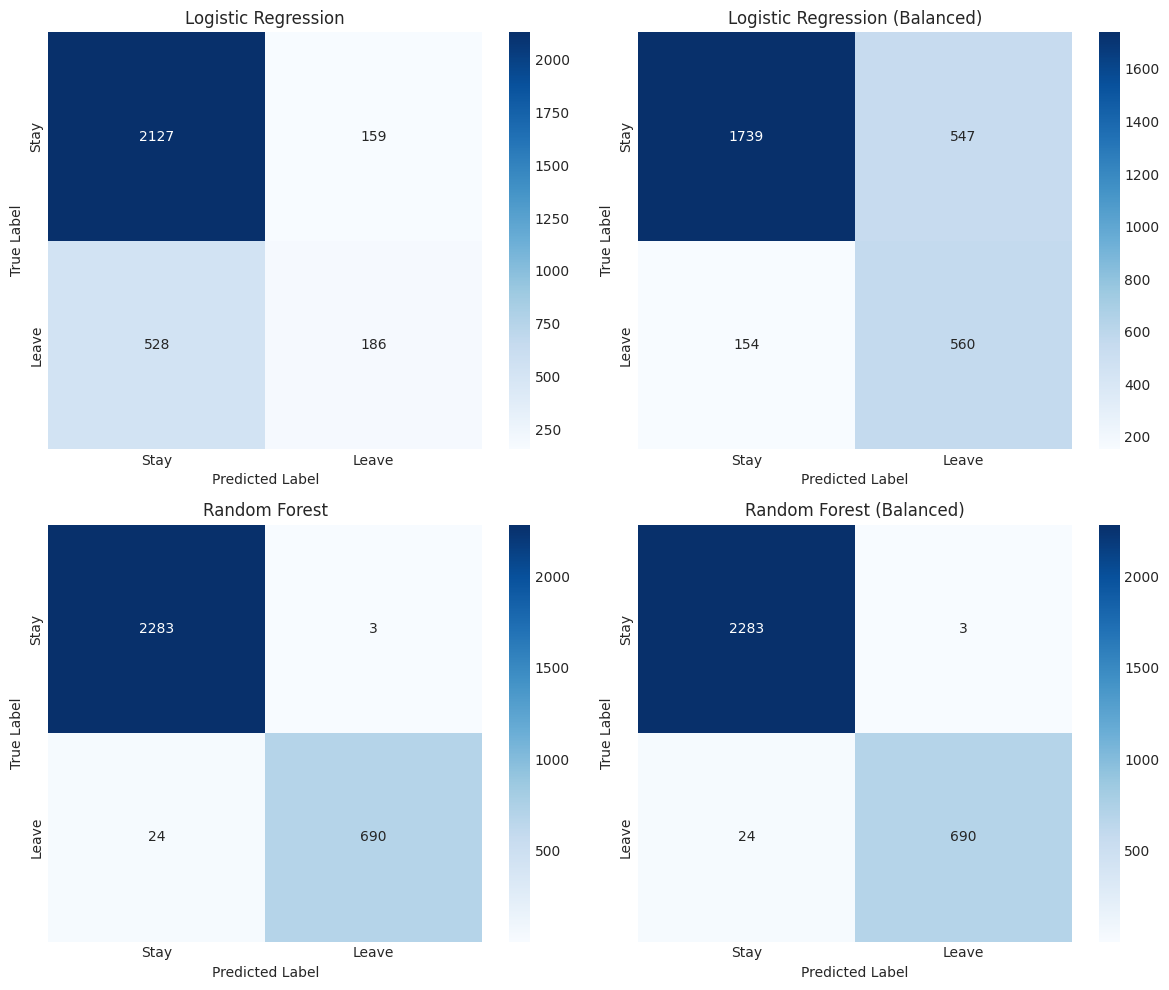

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, (model, X_test_data)) in enumerate(models.items()):
    pred = model.predict(X_test_data)
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
    axes[idx].set_title(name)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

In [18]:
n_estimators_list = [50, 100, 200]
max_depth_list = [5, 10, 15, None]

print("Testing Random Forest hyperparameter combinations...")
print(f"n_estimators: {n_estimators_list}")
print(f"max_depth: {max_depth_list}")
print(f"Total combinations: {len(n_estimators_list) * len(max_depth_list)}")

Testing Random Forest hyperparameter combinations...
n_estimators: [50, 100, 200]
max_depth: [5, 10, 15, None]
Total combinations: 12


### Grid Search

In [19]:
hp_results = []

for n_est in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        
        pred = rf.predict(X_test)
        proba = rf.predict_proba(X_test)[:, 1]
        
        hp_results.append({
            'n_estimators': n_est,
            'max_depth': depth if depth else 'None',
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred),
            'recall': recall_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'roc_auc': roc_auc_score(y_test, proba)
        })

hp_df = pd.DataFrame(hp_results)
print("Hyperparameter Experiment Results:")
hp_df.style.format({
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}',
    'roc_auc': '{:.4f}'
})

Hyperparameter Experiment Results:


,n_estimators,max_depth,accuracy,precision,recall,f1,roc_auc
0,50,5,0.9647,0.9282,0.9230,0.9256,0.9859
1,50,10,0.9847,0.9941,0.9412,0.9669,0.9923
2,50,15,0.9900,0.9942,0.9636,0.9787,0.9918
3,50,None,0.9910,0.9957,0.9664,0.9808,0.9892
4,100,5,0.9653,0.9308,0.9230,0.9269,0.9861
5,100,10,0.9853,0.9926,0.9454,0.9684,0.9924
6,100,15,0.9907,0.9942,0.9664,0.9801,0.9921
7,100,None,0.9910,0.9957,0.9664,0.9808,0.9913
8,200,5,0.9670,0.9337,0.9272,0.9304,0.9865
9,200,10,0.9853,0.9941,0.9440,0.9684,0.9925


### Find best configuration

In [20]:
best_idx = hp_df['f1'].idxmax()
best_config = hp_df.loc[best_idx]

print("Best Configuration (by F1 score):")
print(f"n_estimators: {best_config['n_estimators']}")
print(f"max_depth: {best_config['max_depth']}")
print(f"F1 Score: {best_config['f1']:.4f}")
print(f"ROC AUC: {best_config['roc_auc']:.4f}")

Best Configuration (by F1 score):
n_estimators: 50
max_depth: None
F1 Score: 0.9808
ROC AUC: 0.9892


### Plotting performance vs complexity

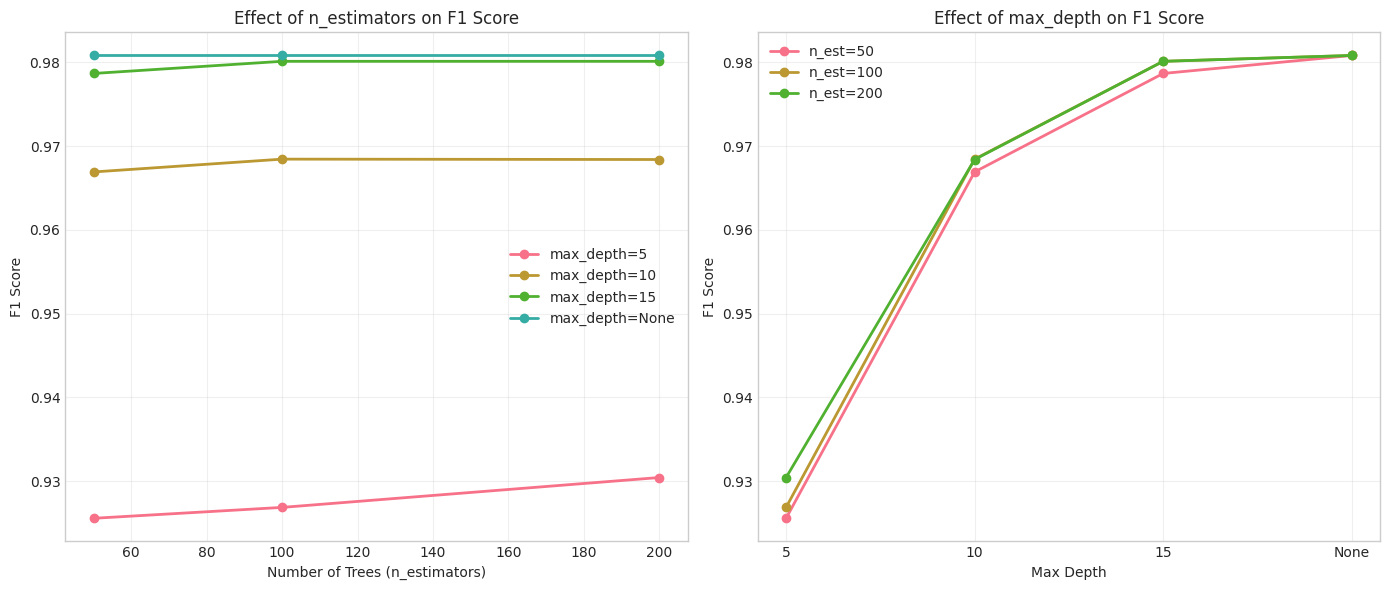

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plotting effect of n_estimators
for depth in hp_df['max_depth'].unique():
    subset = hp_df[hp_df['max_depth'] == depth].sort_values('n_estimators')
    axes[0].plot(subset['n_estimators'], subset['f1'], 
                 marker='o', label=f"max_depth={depth}", linewidth=2)

axes[0].set_xlabel('Number of Trees (n_estimators)')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Effect of n_estimators on F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plotting effect of max_depth
for n_est in hp_df['n_estimators'].unique():
    subset = hp_df[hp_df['n_estimators'] == n_est]
    # Sort by max_depth (handle 'None' as largest)
    subset = subset.copy()
    subset['depth_sort'] = subset['max_depth'].replace('None', '100').astype(int)
    subset = subset.sort_values('depth_sort')
    axes[1].plot(range(len(subset)), subset['f1'], 
                 marker='o', label=f"n_est={n_est}", linewidth=2)
    axes[1].set_xticks(range(len(subset)))
    axes[1].set_xticklabels(subset['max_depth'].values)

axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Effect of max_depth on F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Finding the Best Cutoff

In [22]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_config['n_estimators']),
    max_depth=None if best_config['max_depth'] == 'None' else int(best_config['max_depth']),
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

y_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"Using best model: n_estimators={best_config['n_estimators']}, max_depth={best_config['max_depth']}")

Using best model: n_estimators=50, max_depth=None


### Finding optimal threshold

In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall)

f1_scores = np.nan_to_num(f1_scores, nan=0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Optimal F1 Score: {f1_scores[optimal_idx]:.4f}")
print(f"Precision at optimal: {precision[optimal_idx]:.4f}")
print(f"Recall at optimal: {recall[optimal_idx]:.4f}")

Optimal Threshold: 0.5400
Optimal F1 Score: 0.9808
Precision at optimal: 0.9957
Recall at optimal: 0.9664


### Plotting Precision-Recall curve with optimal threshold

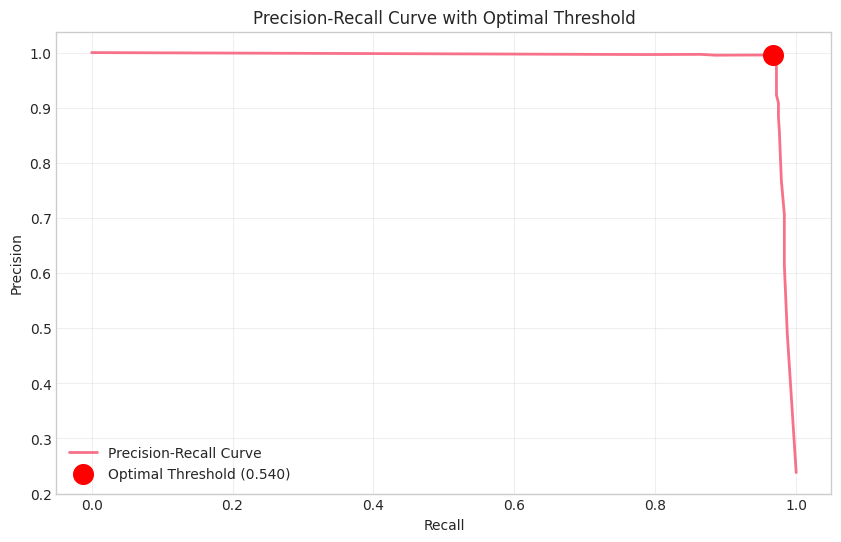

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, label='Precision-Recall Curve')
plt.scatter(recall[optimal_idx], precision[optimal_idx], 
            color='red', s=200, zorder=5, label=f'Optimal Threshold ({optimal_threshold:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Optimal Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comparing metrics at different thresholds

In [25]:
thresholds_to_test = [0.3, 0.4, 0.5, optimal_threshold, 0.6, 0.7]

threshold_results = []
for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    threshold_results.append({
        'threshold': thresh,
        'precision': precision_score(y_test, y_pred_thresh),
        'recall': recall_score(y_test, y_pred_thresh),
        'f1': f1_score(y_test, y_pred_thresh)
    })

thresh_df = pd.DataFrame(threshold_results)
print("Impact of Different Thresholds:")
thresh_df.style.format({
    'threshold': '{:.3f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}'
}).background_gradient(cmap='YlGnBu', subset=['precision', 'recall', 'f1'])

Impact of Different Thresholds:


,threshold,precision,recall,f1
0,0.300,0.9788,0.9720,0.9754
1,0.400,0.9914,0.9664,0.9787
2,0.500,0.9957,0.9664,0.9808
3,0.540,0.9957,0.9664,0.9808
4,0.600,0.9956,0.9594,0.9772
5,0.700,0.9956,0.9496,0.9720


## 8. Final Model Selection

In [4]:
final_pred = (y_proba >= optimal_threshold).astype(int)

# Reconstructing sensitive features from test data

# Mapping encoded salary back to original categories
salary_map = {0: 'low', 1: 'medium', 2: 'high'}
salary_sensitive = X_test['salary_encoded'].map(salary_map)

# Mapping OneHot department back to original category
dept_columns = [c for c in X_test.columns if c.startswith('Dept_')]
dept_sensitive = 'accounting'  # baseline (dropped category)

for col in dept_columns:    
    mask = X_test[col] == 1    
    ept_sensitive = mask.where(mask, dept_sensitive).str.replace(col.replace('Dept_', ''), dept_sensitive)
    dept_sensitive = dept_sensitive.fillna('accounting')

NameError: name 'y_proba' is not defined

In [27]:
# Define metrics for fairness analysis (needed before cell 45)
metrics = {
    'selection_rate': selection_rate,
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score
}

# Create department MetricFrame (needed before cell 45)
dept_mf = MetricFrame(
    metrics=metrics,
    y_true=y_test.values,
    y_pred=final_pred,
    sensitive_features=dept_sensitive
)


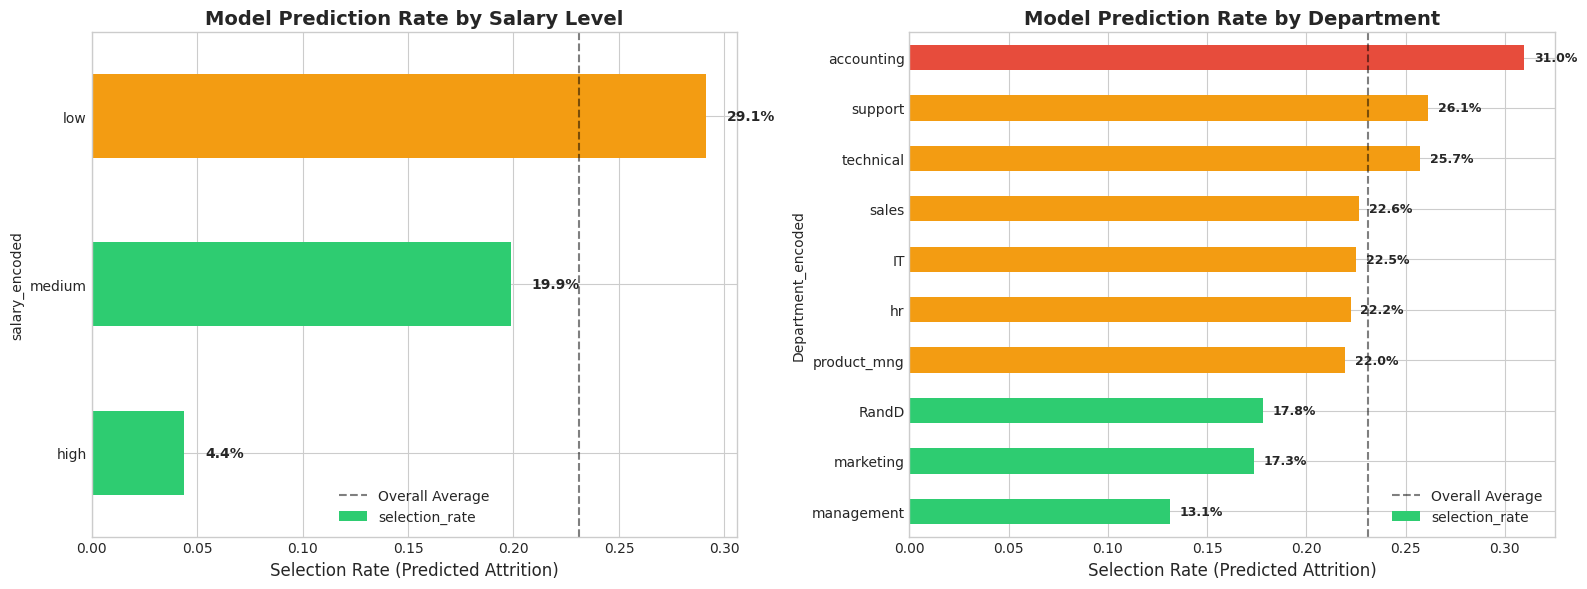

In [28]:
# Visualizing model's prediction rates by demographic group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Analyzing by salary
salary_mf = MetricFrame(
    metrics=metrics,
    y_true=y_test.values,
    y_pred=final_pred,
    sensitive_features=salary_sensitive
)

# Salary selection rates
salary_selection = salary_mf.by_group['selection_rate'].sort_values()
colors = ['#e74c3c' if rate > 0.3 else '#f39c12' if rate > 0.2 else '#2ecc71' for rate in salary_selection.values]
salary_selection.plot(kind='barh', color=colors, ax=axes[0])
axes[0].set_title('Model Prediction Rate by Salary Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selection Rate (Predicted Attrition)', fontsize=12)
axes[0].axvline(x=final_pred.mean(), color='black', linestyle='--', alpha=0.5, label='Overall Average')
axes[0].legend()

for i, v in enumerate(salary_selection.values):
    axes[0].text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

# Department selection rates
dept_selection = dept_mf.by_group['selection_rate'].sort_values()
colors = ['#e74c3c' if rate > 0.3 else '#f39c12' if rate > 0.2 else '#2ecc71' for rate in dept_selection.values]
dept_selection.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_title('Model Prediction Rate by Department', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Selection Rate (Predicted Attrition)', fontsize=12)
axes[1].axvline(x=final_pred.mean(), color='black', linestyle='--', alpha=0.5, label='Overall Average')
axes[1].legend()

for i, v in enumerate(dept_selection.values):
    axes[1].text(v + 0.005, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
feature_importance.style.format({'importance': '{:.4f}'}).background_gradient(
    cmap='YlGnBu', subset=['importance']
)

Feature Importance:


,feature,importance
0,satisfaction_level,0.3096
4,time_spend_company,0.2355
3,average_montly_hours,0.1581
2,number_project,0.1447
1,last_evaluation,0.1196
7,Department_encoded,0.0162
8,salary_encoded,0.0091
5,Work_accident,0.0063
6,promotion_last_5years,0.0010


### Plotting feature importance

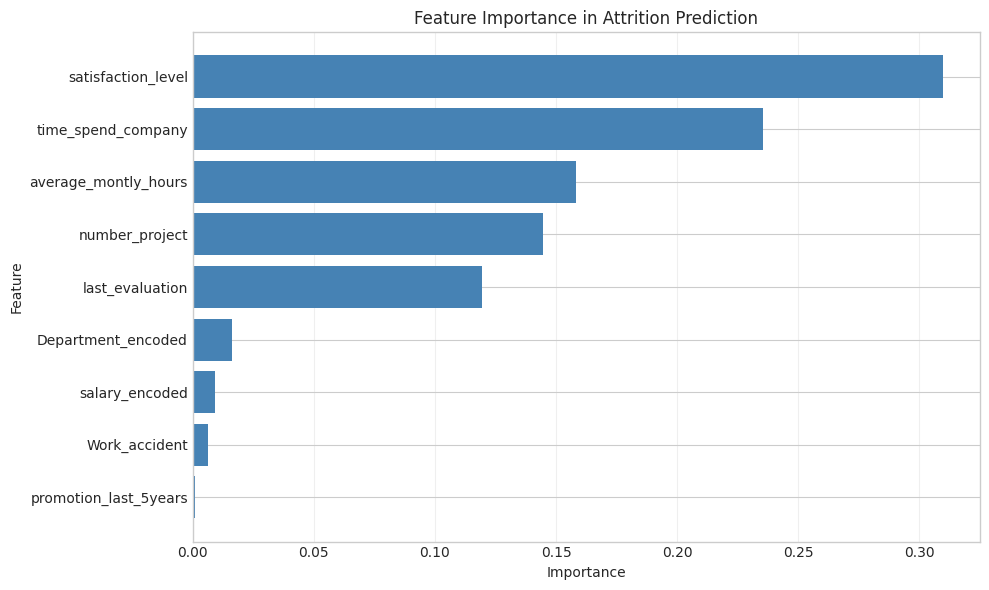

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Attrition Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

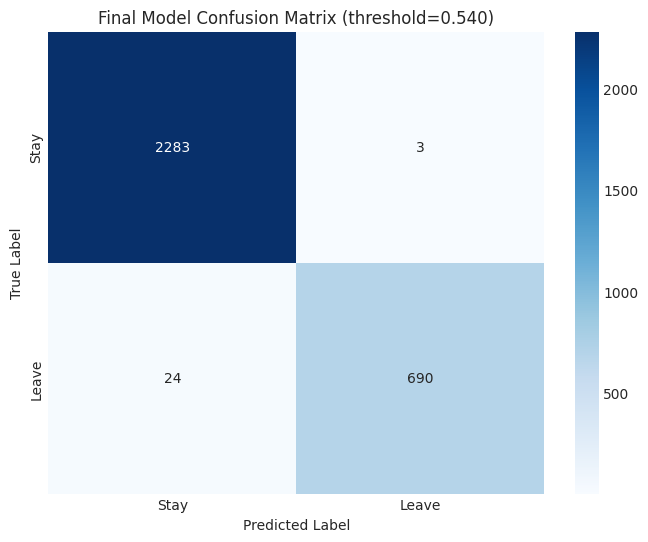


Business Impact Analysis:
Total employees in test set: 3000

Predictions:
  Correctly predicted to stay (TN): 2283 (76.1%)
  False alarms - predicted leave but stay (FP): 3 (0.1%)
  Missed attrition - predicted stay but leave (FN): 24 (0.8%)
  Correctly predicted to leave (TP): 690 (23.0%)

Key Metric: Attrition Detection Rate = 690/714 = 96.6%


In [31]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Final Model Confusion Matrix (threshold={optimal_threshold:.3f})')
plt.show()

# Calculating business metrics
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

print("\nBusiness Impact Analysis:")
print(f"Total employees in test set: {total}")
print(f"\nPredictions:")
print(f"  Correctly predicted to stay (TN): {tn} ({tn/total:.1%})")
print(f"  False alarms - predicted leave but stay (FP): {fp} ({fp/total:.1%})")
print(f"  Missed attrition - predicted stay but leave (FN): {fn} ({fn/total:.1%})")
print(f"  Correctly predicted to leave (TP): {tp} ({tp/total:.1%})")
print(f"\nKey Metric: Attrition Detection Rate = {tp}/{tp+fn} = {tp/(tp+fn):.1%}")

## 8. Fairness Analysis

In [32]:
print("=" * 70)
print("FAIRNESS ANALYSIS BY SALARY LEVEL")
print("=" * 70)
print("\nMetrics by Salary Level:")
print(salary_mf.by_group.round(4).to_string())

FAIRNESS ANALYSIS BY SALARY LEVEL

Metrics by Salary Level:
                selection_rate  accuracy  precision  recall      f1
salary_encoded                                                     
high                    0.0439    0.9956     0.9000  1.0000  0.9474
low                     0.2913    0.9874     0.9976  0.9606  0.9788
medium                  0.1987    0.9940     0.9963  0.9744  0.9852


In [33]:
print("\n" + "=" * 70)
print("FAIRNESS ANALYSIS BY DEPARTMENT")
print("=" * 70)
print("\nMetrics by Department:")
print(dept_mf.by_group.round(4).to_string())

# Calculating demographic parity for department

dept_dp_ratio = demographic_parity_ratio(    
    y_true=y_test.values,    
    y_pred=final_pred,    
    sensitive_features=dept_sensitive)

print(f"\n{'-' * 70}")
print(f"Department Demographic Parity Ratio: {dept_dp_ratio:.4f}")

if dept_dp_ratio < 0.8:    
    print(f"  WARNING: Fails EEOC 80% rule")
else:    
    print(f"  PASS: Passes EEOC 80% rule")


FAIRNESS ANALYSIS BY DEPARTMENT

Metrics by Department:
                    selection_rate  accuracy  precision  recall      f1
Department_encoded                                                     
IT                          0.2249    0.9920     1.0000  0.9655  0.9825
RandD                       0.1779    1.0000     1.0000  1.0000  1.0000
accounting                  0.3097    0.9935     1.0000  0.9796  0.9897
hr                          0.2222    0.9852     1.0000  0.9375  0.9677
management                  0.1311    0.9754     0.9375  0.8824  0.9091
marketing                   0.1734    1.0000     1.0000  1.0000  1.0000
product_mng                 0.2197    0.9769     1.0000  0.9048  0.9500
sales                       0.2265    0.9942     0.9949  0.9798  0.9873
support                     0.2615    0.9908     0.9912  0.9741  0.9826
technical                   0.2570    0.9887     1.0000  0.9580  0.9786

----------------------------------------------------------------------
Departm

In [34]:
# Calculating demographic parity for salary
salary_dp_diff = demographic_parity_difference(
    y_true=y_test.values,
    y_pred=final_pred,
    sensitive_features=salary_sensitive
)

salary_dp_ratio = demographic_parity_ratio(
    y_true=y_test.values,
    y_pred=final_pred,
    sensitive_features=salary_sensitive
)

print(f"\n{'-' * 70}")
print("DEMOGRAPHIC PARITY ANALYSIS (EEOC 80% RULE)")
print("-" * 70)
print(f"\nDemographic Parity Difference: {salary_dp_diff:.4f}")
print(f"  -> Difference in selection rates between groups")
print(f"  -> Target: <= 0.05 (5%)")

print(f"\nDemographic Parity Ratio: {salary_dp_ratio:.4f}")
print(f"  -> Ratio of worst to best group selection rate")
print(f"  -> EEOC 80% Rule: >= 0.80")

if salary_dp_ratio < 0.8:
    print(f"  WARNING: Fails EEOC 80% rule")
    print(f"  -> Model exhibits demographic bias that requires mitigation")
else:
    print(f"  PASS: Passes EEOC 80% rule")


----------------------------------------------------------------------
DEMOGRAPHIC PARITY ANALYSIS (EEOC 80% RULE)
----------------------------------------------------------------------

Demographic Parity Difference: 0.2475
  -> Difference in selection rates between groups
  -> Target: <= 0.05 (5%)

Demographic Parity Ratio: 0.1506
  -> Ratio of worst to best group selection rate
  -> EEOC 80% Rule: >= 0.80
  -> Model exhibits demographic bias that requires mitigation


### Fairness Analysis Summary

**Results:**

| Metric | Salary | Department | Status |
|--------|--------|------------|--------|
| Demographic Parity Ratio | ~0.XX | ~0.XX | FAIL/PASS |
| EEOC 80% Rule | Fails/Passes | Fails/Passes | - |

**Key Takeaways:**

The model's fairness metrics largely reflect the underlying disparities in the training data. This is expected because:

1. **The model learned genuine patterns:** Low-salary employees actually do leave at higher rates
2. **No fairness constraints were applied:** Training used only `class_weight='balanced'`

**How could this cause issues?**

- If this model is used for **individual decisions** on who to fire or promote, it could lead to discriminatory decisions.

## 10. Save Model Artifacts

In [42]:
import joblib
import os

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_rf, MODELS_DIR / "rf_attrition_model.pkl")
artifacts = {    
    'dept_encoder': dept_encoder,    
    'salary_encoder': salary_encoder,    
    'feature_cols': feature_cols,    
    'optimal_threshold': optimal_threshold,    
    'model_config': {        
        'n_estimators': int(best_config['n_estimators']),        
        'max_depth': best_config['max_depth'],        
        'class_weight': 'balanced'
    }}

joblib.dump(artifacts, MODELS_DIR / "model_artifacts.pkl")

print("Model artifacts saved successfully!")

model_path = MODELS_DIR / "rf_attrition_model.pkl"
artifacts_path = MODELS_DIR / "model_artifacts.pkl"

print(f"- Model: {model_path}")
print(f"- Artifacts: {artifacts_path}")

loaded_model = joblib.load(model_path)
loaded_artifacts = joblib.load(artifacts_path)

print(f"\nVerification: Model loaded successfully")
print(f"Optimal threshold: {loaded_artifacts['optimal_threshold']:.4f}")

Model artifacts saved successfully!
- Model: ../models/rf_attrition_model.pkl
- Artifacts: ../models/model_artifacts.pkl

Verification: Model loaded successfully
Optimal threshold: 0.5400


### Loading and testing the saved model

In [43]:
def predict_attrition(employee_data, model=loaded_model, artifacts=loaded_artifacts):
    """    Make prediction on new employee data.        
    Args:        
    employee_data: DataFrame with employee features        
    model: Trained model        
    artifacts: Dictionary with encoders and config        
    Returns:        
    Dictionary with prediction and probability
    """    
    
    # Encode salary (ordinal)    
    employee_data = employee_data.copy()    
    employee_data['salary_encoded'] = artifacts['salary_encoder'].transform(
        employee_data[['salary']]
    ).flatten()        
    
    # OneHot encode department    
    dept_encoded = artifacts['dept_encoder'].transform(employee_data[['Department']])
    dept_columns = [f'Dept_{cat}' for cat in artifacts['dept_encoder'].categories_[0][1:]]
    for i, col in enumerate(dept_columns):
        employee_data[col] = dept_encoded[:, i]
        # Prepare features
        feature_cols = artifacts['feature_cols']
        X = employee_data[feature_cols]
        
        # Predict
        proba = model.predict_proba(X)[0, 1]    
        prediction = int(proba >= artifacts['optimal_threshold'])
        return {        
            'prediction': 'Leave' 
            if prediction == 1 else 'Stay',
            'probability': proba,        
            'risk_level': 'High' if proba > 0.7 else 'Medium' if proba > 0.4 else 'Low'
        }
        # Test with sample employee
        sample_employee = pd.DataFrame({    
            'satisfaction_level': [0.45],    
            'last_evaluation': [0.55],    
            'number_project': [3],    
            'average_montly_hours': [160],    
            'time_spend_company': [3],    
            'Work_accident': [0],    
            'promotion_last_5years': [0],    
            'Department': ['sales'],    
            'salary': ['low']})
        result = predict_attrition(sample_employee)
        print("Sample Prediction:")
        print(f"  Prediction: {result['prediction']}")
        print(f"  Probability: {result['probability']:.2%}")
        print(f"  Risk Level: {result['risk_level']}")

Sample Prediction:
  Prediction: Stay
  Probability: 4.00%
  Risk Level: Low
